# Monte Carlo Portfolio Risk Simulator

In this notebook, we download historical price data for a set of financial assets and prepare the return data that will later be used for Monte Carlo simulation.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
from pathlib import Path

# Project folders
PROJECT_ROOT = Path.cwd()

# If the notebook is running from the "notebooks" folder, go one level up
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

# Assets used in the project
tickers = ["SPY", "QQQ", "TLT", "GLD"]

# Download historical adjusted price data
prices = yf.download(
    tickers,
    start="2018-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

# Remove missing values
prices = prices.dropna()

# Save prices to CSV
prices.to_csv(DATA_DIR / "asset_prices.csv")

print("Data downloaded successfully.")
print(f"Number of observations: {prices.shape[0]}")
print(f"Number of assets: {prices.shape[1]}")

prices.tail()

Data downloaded successfully.
Number of observations: 2138
Number of assets: 4


Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-06-30,368.380005,736.400024,746.770020,86.101997
2026-07-01,370.600006,725.169983,745.760010,85.519997
2026-07-02,378.130005,712.599976,744.780029,85.510002
2026-07-06,382.130005,722.820007,751.280029,85.449997
2026-07-07,377.489990,709.429993,747.710022,84.550003


In [6]:
# Calculate daily returns
returns = prices.pct_change().dropna()

# Save daily returns to CSV
returns.to_csv(DATA_DIR / "daily_returns.csv")

print("Daily returns calculated successfully.")
print(f"Number of return observations: {returns.shape[0]}")
print(f"Number of assets: {returns.shape[1]}")

returns.tail()

Daily returns calculated successfully.
Number of return observations: 2137
Number of assets: 4


Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-06-30,-0.000543,0.017015,0.007787,-0.011778
2026-07-01,0.006026,-0.015250,-0.001353,-0.006759
2026-07-02,0.020318,-0.017334,-0.001314,-0.000117
2026-07-06,0.010578,0.014342,0.008727,-0.000702
2026-07-07,-0.012143,-0.018525,-0.004752,-0.010532


## Return Analysis

In this section, we analyze the daily returns of the selected assets. We calculate average returns, volatility, annualized performance metrics, and the correlation matrix.

In [7]:
# Summary statistics for daily returns
summary_stats = pd.DataFrame({
    "Mean Daily Return": returns.mean(),
    "Daily Volatility": returns.std(),
    "Annualized Return": returns.mean() * 252,
    "Annualized Volatility": returns.std() * np.sqrt(252)
})

summary_stats

,Mean Daily Return,Daily Volatility,Annualized Return,Annualized Volatility
Ticker,,,,
GLD,0.000573,0.010593,0.144420,0.168165
QQQ,0.000841,0.015056,0.211857,0.239006
SPY,0.000613,0.012081,0.154481,0.191786
TLT,-0.000025,0.009735,-0.006353,0.154546


In [8]:
# Correlation matrix
correlation_matrix = returns.corr()

correlation_matrix

Ticker,GLD,QQQ,SPY,TLT
Ticker,,,,
GLD,1.000000,0.127393,0.115128,0.226904
QQQ,0.127393,1.000000,0.936441,-0.089177
SPY,0.115128,0.936441,1.000000,-0.138258
TLT,0.226904,-0.089177,-0.138258,1.000000


## Historical Price Performance

To compare the performance of assets with different price levels, we normalize all prices to 100 at the beginning of the period.

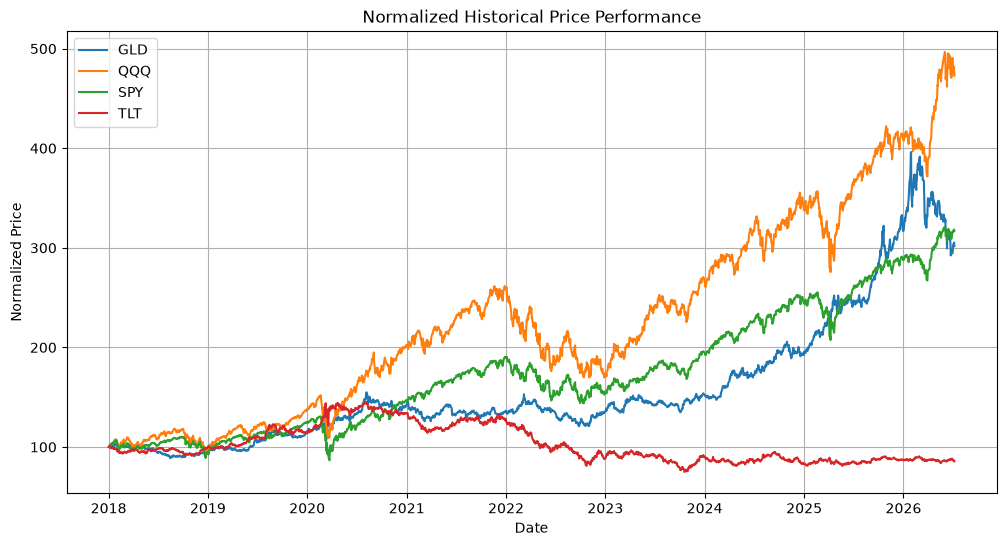

In [9]:
# Normalize prices to 100 at the beginning of the period
normalized_prices = prices / prices.iloc[0] * 100

# Plot normalized prices
plt.figure(figsize=(12, 6))
plt.plot(normalized_prices)
plt.title("Normalized Historical Price Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend(normalized_prices.columns)
plt.grid(True)
plt.show()

## Monte Carlo Simulation

In this section, we simulate thousands of possible future portfolio paths using historical mean returns, volatility, and correlations between assets.

In [10]:
# Portfolio weights
# The weights must sum to 1.0
weights = pd.Series({
    "SPY": 0.40,   # S&P 500 ETF
    "QQQ": 0.30,   # Nasdaq 100 ETF
    "TLT": 0.20,   # Long-term Treasury bonds ETF
    "GLD": 0.10    # Gold ETF
})

# Reorder weights to match the returns columns
weights = weights[returns.columns]

weights

Ticker
GLD    0.1
QQQ    0.3
SPY    0.4
TLT    0.2
dtype: float64

In [11]:
# Monte Carlo simulation settings
initial_portfolio_value = 10_000
n_simulations = 10_000
time_horizon = 252  # approximately one trading year

# Historical mean returns and covariance matrix
mean_returns = returns.mean()
cov_matrix = returns.cov()

# Set random seed for reproducibility
np.random.seed(42)

# Simulate correlated daily returns
simulated_returns = np.random.multivariate_normal(
    mean=mean_returns,
    cov=cov_matrix,
    size=(n_simulations, time_horizon)
)

# Calculate simulated portfolio daily returns
simulated_portfolio_returns = simulated_returns @ weights.values

# Convert daily returns into portfolio value paths
portfolio_values = initial_portfolio_value * np.cumprod(
    1 + simulated_portfolio_returns,
    axis=1
)

# Final portfolio values after one year
final_values = portfolio_values[:, -1]

print("Monte Carlo simulation completed.")
print(f"Number of simulations: {n_simulations}")
print(f"Time horizon: {time_horizon} trading days")
print(f"Initial portfolio value: ${initial_portfolio_value:,.2f}")
print(f"Average final value: ${final_values.mean():,.2f}")

Monte Carlo simulation completed.
Number of simulations: 10000
Time horizon: 252 trading days
Initial portfolio value: $10,000.00
Average final value: $11,500.85


## Simulated Portfolio Paths

The chart below shows a sample of simulated portfolio value paths over a one-year horizon. Each line represents one possible future scenario generated by the Monte Carlo simulation.

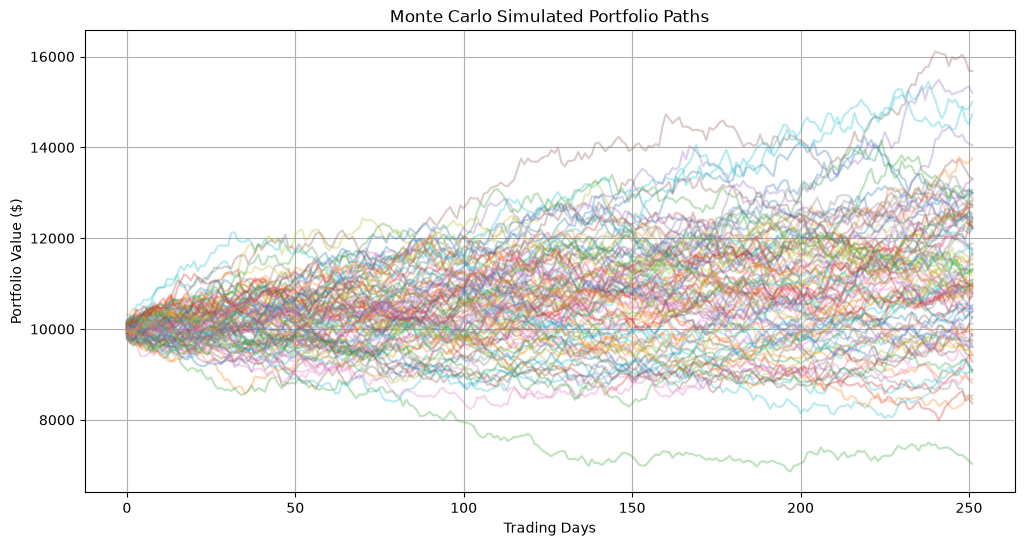

In [12]:
# Create images folder if it does not exist
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

# Plot a sample of simulated portfolio paths
plt.figure(figsize=(12, 6))

for i in range(100):
    plt.plot(portfolio_values[i], alpha=0.3)

plt.title("Monte Carlo Simulated Portfolio Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)

# Save chart
plt.savefig(IMAGES_DIR / "monte_carlo_paths.png", dpi=300, bbox_inches="tight")

plt.show()

## Risk Metrics: VaR and Expected Shortfall

We analyze the distribution of final portfolio values after one year and estimate downside risk using Value at Risk and Expected Shortfall.

In [13]:
# Calculate portfolio returns after one year
portfolio_returns_1y = final_values / initial_portfolio_value - 1

# Risk metrics
mean_final_value = final_values.mean()
median_final_value = np.median(final_values)

probability_of_loss = np.mean(final_values < initial_portfolio_value)

var_95 = np.percentile(portfolio_returns_1y, 5)
expected_shortfall_95 = portfolio_returns_1y[portfolio_returns_1y <= var_95].mean()

print("Risk Metrics")
print("------------------------------")
print(f"Mean final portfolio value: ${mean_final_value:,.2f}")
print(f"Median final portfolio value: ${median_final_value:,.2f}")
print(f"Probability of loss: {probability_of_loss:.2%}")
print(f"95% Value at Risk: {var_95:.2%}")
print(f"95% Expected Shortfall: {expected_shortfall_95:.2%}")

Risk Metrics
------------------------------
Mean final portfolio value: $11,500.85
Median final portfolio value: $11,382.97
Probability of loss: 19.30%
95% Value at Risk: -11.16%
95% Expected Shortfall: -16.44%


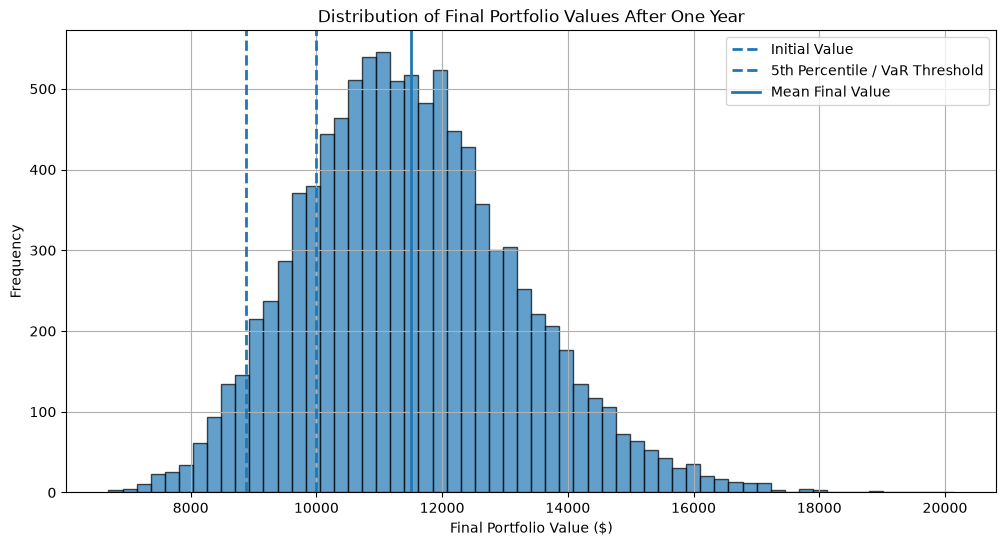

In [14]:
# Plot distribution of final portfolio values
plt.figure(figsize=(12, 6))

plt.hist(final_values, bins=60, edgecolor="black", alpha=0.7)

plt.axvline(initial_portfolio_value, linestyle="--", linewidth=2, label="Initial Value")
plt.axvline(np.percentile(final_values, 5), linestyle="--", linewidth=2, label="5th Percentile / VaR Threshold")
plt.axvline(mean_final_value, linestyle="-", linewidth=2, label="Mean Final Value")

plt.title("Distribution of Final Portfolio Values After One Year")
plt.xlabel("Final Portfolio Value ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

# Save chart
plt.savefig(IMAGES_DIR / "final_value_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Final Results Summary

The table below summarizes the main risk and return metrics from the Monte Carlo simulation.

In [15]:
# Create outputs folder if it does not exist
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

# Create final results summary
results_summary = pd.DataFrame({
    "Metric": [
        "Initial Portfolio Value",
        "Mean Final Value",
        "Median Final Value",
        "Probability of Loss",
        "95% Value at Risk",
        "95% Expected Shortfall"
    ],
    "Value": [
        initial_portfolio_value,
        mean_final_value,
        median_final_value,
        probability_of_loss,
        var_95,
        expected_shortfall_95
    ]
})

# Save results to CSV
results_summary.to_csv(OUTPUTS_DIR / "risk_metrics_summary.csv", index=False)

results_summary

,Metric,Value
0,Initial Portfolio Value,10000.000000
1,Mean Final Value,11500.850986
2,Median Final Value,11382.972590
3,Probability of Loss,0.193000
4,95% Value at Risk,-0.111579
5,95% Expected Shortfall,-0.164366


## Interpretation of Results

The Monte Carlo simulation provides a range of possible outcomes for the portfolio over a one-year horizon.

The average final portfolio value represents the expected outcome across all simulated scenarios, while the median final value shows the midpoint of the distribution.

The probability of loss measures how often the simulated portfolio ends below the initial value of $10,000.

The 95% Value at Risk estimates the loss threshold in the worst 5% of simulated outcomes. In other words, under the assumptions of the model, there is a 5% probability that the portfolio return will be lower than this value.

The 95% Expected Shortfall measures the average return within the worst 5% of scenarios. This is useful because it gives more information about tail risk than VaR alone.

Overall, this simulation helps evaluate the downside risk of a multi-asset portfolio by combining historical returns, volatility, and correlations between assets.

## Portfolio Comparison

In this section, we compare three different portfolio allocations: Conservative, Balanced, and Aggressive.

Each portfolio is simulated using the same Monte Carlo framework. The objective is to compare expected final value, probability of loss, Value at Risk, and Expected Shortfall across different risk profiles.

In [16]:
# Define multiple portfolio allocations
portfolios = {
    "Conservative": {
        "SPY": 0.20,
        "QQQ": 0.10,
        "TLT": 0.50,
        "GLD": 0.20
    },
    "Balanced": {
        "SPY": 0.40,
        "QQQ": 0.30,
        "TLT": 0.20,
        "GLD": 0.10
    },
    "Aggressive": {
        "SPY": 0.50,
        "QQQ": 0.40,
        "TLT": 0.05,
        "GLD": 0.05
    }
}

portfolios

{'Conservative': {'SPY': 0.2, 'QQQ': 0.1, 'TLT': 0.5, 'GLD': 0.2},
 'Balanced': {'SPY': 0.4, 'QQQ': 0.3, 'TLT': 0.2, 'GLD': 0.1},
 'Aggressive': {'SPY': 0.5, 'QQQ': 0.4, 'TLT': 0.05, 'GLD': 0.05}}

In [17]:
def run_monte_carlo_simulation(
    weights_dict,
    returns,
    initial_value=10_000,
    n_simulations=10_000,
    time_horizon=252
):
    """
    Runs a Monte Carlo simulation for a given portfolio allocation.
    """
    weights = pd.Series(weights_dict)
    weights = weights[returns.columns]

    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    simulated_returns = np.random.multivariate_normal(
        mean=mean_returns,
        cov=cov_matrix,
        size=(n_simulations, time_horizon)
    )

    simulated_portfolio_returns = simulated_returns @ weights.values

    portfolio_values = initial_value * np.cumprod(
        1 + simulated_portfolio_returns,
        axis=1
    )

    final_values = portfolio_values[:, -1]
    portfolio_returns_1y = final_values / initial_value - 1

    var_95 = np.percentile(portfolio_returns_1y, 5)
    expected_shortfall_95 = portfolio_returns_1y[
        portfolio_returns_1y <= var_95
    ].mean()

    results = {
        "Mean Final Value": final_values.mean(),
        "Median Final Value": np.median(final_values),
        "Probability of Loss": np.mean(final_values < initial_value),
        "95% Value at Risk": var_95,
        "95% Expected Shortfall": expected_shortfall_95
    }

    return results, portfolio_values, final_values

In [18]:
# Run simulations for all portfolios
np.random.seed(42)

comparison_results = {}
portfolio_paths = {}
portfolio_final_values = {}

for portfolio_name, allocation in portfolios.items():
    results, simulated_paths, final_vals = run_monte_carlo_simulation(
        allocation,
        returns,
        initial_value=initial_portfolio_value,
        n_simulations=n_simulations,
        time_horizon=time_horizon
    )

    comparison_results[portfolio_name] = results
    portfolio_paths[portfolio_name] = simulated_paths
    portfolio_final_values[portfolio_name] = final_vals

comparison_table = pd.DataFrame(comparison_results).T

comparison_table

,Mean Final Value,Median Final Value,Probability of Loss,95% Value at Risk,95% Expected Shortfall
Conservative,10819.127422,10763.251286,0.2421,-0.099117,-0.137402
Balanced,11482.348884,11355.811978,0.1996,-0.111888,-0.163061
Aggressive,11848.735924,11641.125315,0.2143,-0.150321,-0.214581


In [19]:
# Add historical portfolio metrics: annualized return, volatility, and Sharpe Ratio

risk_free_rate = 0.00  # simplified assumption

historical_metrics = {}

for portfolio_name, allocation in portfolios.items():
    weights = pd.Series(allocation)
    weights = weights[returns.columns]

    portfolio_daily_returns = returns @ weights.values

    annualized_return = portfolio_daily_returns.mean() * 252
    annualized_volatility = portfolio_daily_returns.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

    historical_metrics[portfolio_name] = {
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio
    }

historical_metrics_table = pd.DataFrame(historical_metrics).T

# Combine Monte Carlo risk metrics with historical return/risk metrics
comparison_table_extended = comparison_table.join(historical_metrics_table)

comparison_table_extended

,Mean Final Value,Median Final Value,Probability of Loss,95% Value at Risk,95% Expected Shortfall,Annualized Return,Annualized Volatility,Sharpe Ratio
Conservative,10819.127422,10763.251286,0.2421,-0.099117,-0.137402,0.077789,0.106743,0.728752
Balanced,11482.348884,11355.811978,0.1996,-0.111888,-0.163061,0.138521,0.149518,0.926453
Aggressive,11848.735924,11641.125315,0.2143,-0.150321,-0.214581,0.168887,0.188994,0.893608


In [20]:
# Save portfolio comparison results
comparison_table_extended.to_csv(
    OUTPUTS_DIR / "portfolio_comparison_summary.csv"
)

comparison_table_extended

,Mean Final Value,Median Final Value,Probability of Loss,95% Value at Risk,95% Expected Shortfall,Annualized Return,Annualized Volatility,Sharpe Ratio
Conservative,10819.127422,10763.251286,0.2421,-0.099117,-0.137402,0.077789,0.106743,0.728752
Balanced,11482.348884,11355.811978,0.1996,-0.111888,-0.163061,0.138521,0.149518,0.926453
Aggressive,11848.735924,11641.125315,0.2143,-0.150321,-0.214581,0.168887,0.188994,0.893608


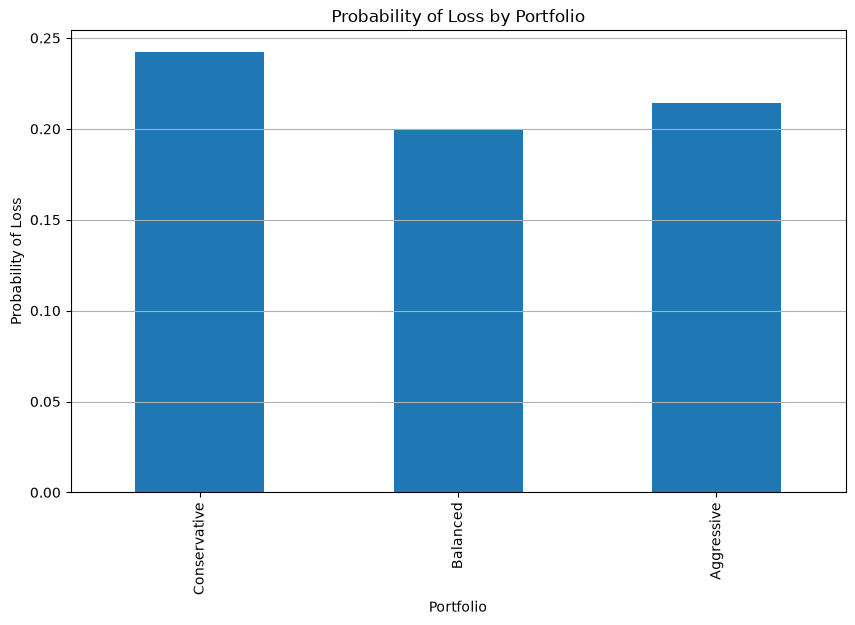

In [21]:
plt.figure(figsize=(10, 6))

comparison_table_extended["Probability of Loss"].plot(kind="bar")

plt.title("Probability of Loss by Portfolio")
plt.xlabel("Portfolio")
plt.ylabel("Probability of Loss")
plt.grid(axis="y")

plt.savefig(IMAGES_DIR / "probability_of_loss_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

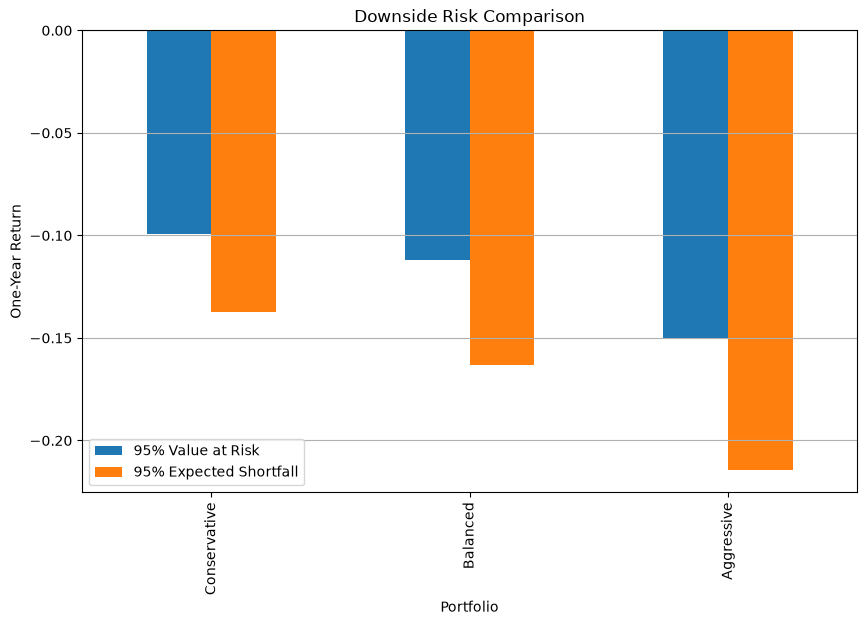

In [22]:
risk_comparison = comparison_table_extended[
    ["95% Value at Risk", "95% Expected Shortfall"]
]

ax = risk_comparison.plot(kind="bar", figsize=(10, 6))

plt.title("Downside Risk Comparison")
plt.xlabel("Portfolio")
plt.ylabel("One-Year Return")
plt.grid(axis="y")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "var_expected_shortfall_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

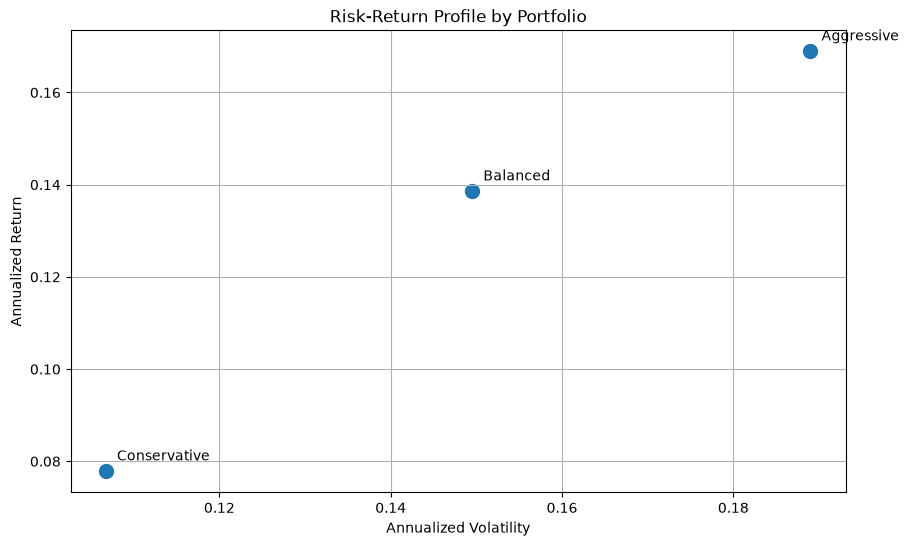

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    comparison_table_extended["Annualized Volatility"],
    comparison_table_extended["Annualized Return"],
    s=100
)

for portfolio_name in comparison_table_extended.index:
    plt.annotate(
        portfolio_name,
        (
            comparison_table_extended.loc[portfolio_name, "Annualized Volatility"],
            comparison_table_extended.loc[portfolio_name, "Annualized Return"]
        ),
        textcoords="offset points",
        xytext=(8, 8)
    )

plt.title("Risk-Return Profile by Portfolio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.grid(True)

plt.savefig(IMAGES_DIR / "risk_return_profile.png", dpi=300, bbox_inches="tight")

plt.show()

## Portfolio Comparison Interpretation

The Conservative portfolio has the lowest risk profile, mainly because it has a larger allocation to long-term Treasury bonds and gold. As a result, it generally shows lower downside risk, but also a lower expected return.

The Balanced portfolio provides a middle-ground allocation between equities, bonds, and gold. It offers higher expected return than the Conservative portfolio, while still keeping some diversification benefits.

The Aggressive portfolio has the highest exposure to SPY and QQQ, which increases its expected return but also increases volatility and downside risk. This portfolio is more sensitive to equity market movements.

Overall, the comparison highlights the trade-off between risk and return: portfolios with higher equity exposure tend to generate higher expected returns, but they also have a higher probability of loss and worse downside risk metrics.